In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

In [26]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.84,e=0.05,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636723853e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 8183.49it/s]

-8.88016663672394e-05
Energy Percent Change: 9.767403850299797e-13 %
*** Simulation Complete ***
Time elapsed  = 12.22416443599991 seconds


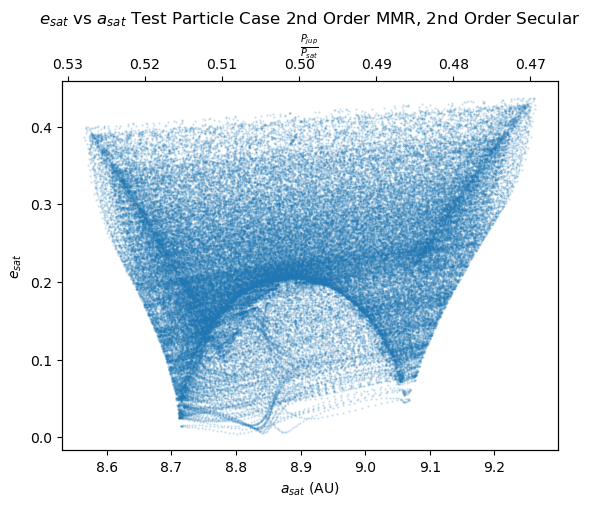

In [27]:
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_2dn_ord_MMR, e_sat_2dn_ord_MMR, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_2dn_ord_MMR**3)/np.sqrt(a_sat_2dn_ord_MMR**3), e_sat_2dn_ord_MMR, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()